In [ ]:
# Print a simple test message to verify the notebook is running
# "RAG" stands for "Retrieval-Augmented Generation" - a pattern we'll explore in this notebook
print("Hello RAG")

Hello RAG


In [ ]:
# This line installs the langchain-groq package using pip
# langchain-groq is a connector that allows LangChain to use Groq's fast LLM API
# The exclamation mark (!) tells Jupyter to run this as a shell command instead of Python
# This package provides ChatGroq - a wrapper around Groq's API with LangChain's standard interface
!pip install langchain-groq

In [ ]:

# =============================================================================
# CELL: Imports and offline setup
# =============================================================================
# We check what's installed and set up fake models so everything runs offline.

# Import the 'os' module to work with environment variables and file paths
import os
# Import 'json' to handle JSON data serialization and deserialization
import json
# Import specific type hints from typing module:
#   - Any: accepts any type
#   - Callable: for functions/methods
#   - Literal: for values restricted to specific options
#   - Optional: for values that can be None
from typing import Any, Callable, Literal, Optional

# --- Check what's available -------------------------------------------------
# Initialize HAVE_LANGCHAIN as False - we'll set it to True if import succeeds
HAVE_LANGCHAIN = False
# Try to import LangChain libraries - this will fail gracefully if not installed
try:
    # Import the main langchain module (the high-level framework)
    import langchain
    # Import langchain_core (the low-level building blocks that everything uses)
    import langchain_core
    # If both imports succeeded, set the flag to True so we know they're available
    HAVE_LANGCHAIN = True
    # Print the version of langchain we have installed (or 'unknown' if not available)
    print(f"langchain      : {getattr(langchain, '__version__', 'unknown')}")
    # Print the version of langchain-core (the underlying library)
    print(f"langchain-core : {getattr(langchain_core, '__version__', 'unknown')}")
# If the import fails, this except block catches the error and continues gracefully
except ImportError:
    # Print a message letting the user know langchain is not installed
    print("langchain not installed.")
    # Provide the command the user can run to install all needed packages
    print("Install with:  pip install langchain langgraph langchain-openai")

# Initialize HAVE_LANGGRAPH as False - we'll set it to True if import succeeds
HAVE_LANGGRAPH = False
# Try to import langgraph - this is the newer graph-based workflow library
try:
    # Import the langgraph module (used for building agent workflows)
    import langgraph
    # If import succeeded, set the flag to True
    HAVE_LANGGRAPH = True
    # Print the version of langgraph we have installed
    print(f"langgraph      : {getattr(langgraph, '__version__', 'unknown')}")
# If the import fails, catch the error and continue
except ImportError:
    # Print a message letting the user know langgraph is not installed
    print("langgraph not installed.")

# Print a blank line for readability
print()
# Print a note about the version we're using (important for compatibility)
print("NOTE: This notebook is written for langchain>=1.0 (the Oct 2025 rewrite).")
# Warn users that if they have an older version, the APIs shown here won't work
print("If you have 0.3.x, the agent APIs shown here will not exist.")

langchain      : 1.3.18
langchain-core : 1.6.1
langgraph      : unknown

NOTE: This notebook is written for langchain>=1.0 (the Oct 2025 rewrite).
If you have 0.3.x, the agent APIs shown here will not exist.


In [ ]:

# =============================================================================
# CELL: Fake models - learn the API without an API key
# =============================================================================
# langchain-core ships fake chat models for testing. They implement the exact
# same interface as ChatOpenAI/ChatAnthropic, so every pattern you learn here
# transfers directly to production.

# Only run this cell if langchain is installed (checked in previous cell)
if HAVE_LANGCHAIN:
    # Import FakeListChatModel - a fake model that returns canned responses in order
    # This is useful for testing without calling a real API
    from langchain_core.language_models.fake_chat_models import (
        FakeListChatModel,        # Returns a fixed list of responses in order each time you call it
        GenericFakeChatModel,     # More flexible - lets you customize responses with AIMessages
    )
    # Import message types that represent different roles in a conversation:
    #   - AIMessage: message from the AI/assistant
    #   - HumanMessage: message from the user
    #   - SystemMessage: system instructions sent to the model
    #   - ToolMessage: responses from tool calls
    #   - BaseMessage: base class for all message types
    from langchain_core.messages import (
        AIMessage, HumanMessage, SystemMessage, ToolMessage, BaseMessage,
    )

    # Create a fake model that cycles through canned responses
    # Each time you call .invoke(), it returns the next response in the list
    # This line demonstrates the key learning point - how to instantiate a model
    # In production this line becomes:
    #     from langchain_openai import ChatOpenAI
    #     model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    # Notice the interface is IDENTICAL - same .invoke() method, same message handling
    fake_model = FakeListChatModel(responses=[
        "Paris is the capital of France.",
        "The Eiffel Tower is 330 metres tall.",
        "I don't have that information.",
    ])

    # Print a header explaining what we're about to demonstrate
    print("Fake model created. Testing the standard interface:\n")

    # --- Show the universal interface ---
    # .invoke() is THE universal method. Every LangChain component has it.
    # This is how you:
    #   1. Send input to any component (models, chains, tools, etc.)
    #   2. Get output back synchronously
    # Example (commented out - uncomment to test):
    #  response = fake_model.invoke("What is the capital of France?")
    # print(f"  type(response) = {type(response).__name__}")    # Will be AIMessage
    # print(f"  response.content = {response.content!r}")       # Will be "Paris is the capital of France."
    
    # Print a blank line for readability
    print()
    # Print the key learning point: the interface is the same across all models
    print("  This is EXACTLY the interface a real ChatOpenAI has.")
    # Print the most important insight: you can swap fake → real models without changing code
    print("  Swap the model line and everything else stays identical.")
# If langchain is not installed, skip this cell
else:
    print("Skipping - langchain not installed.")

Fake model created. Testing the standard interface:

  type(response) = AIMessage
  response.content = 'Paris is the capital of France.'

  This is EXACTLY the interface a real ChatOpenAI has.
  Swap the model line and everything else stays identical.


In [ ]:
# Import the 'os' module again to access environment variables
import os
# Import ChatGroq - a wrapper around Groq's fast LLM API that works with LangChain
# Groq specializes in fast token generation using specialized hardware
from langchain_groq import ChatGroq

# 2. Set your API key (get one free at https://console.groq.com/keys)
# Store the Groq API key in the OS environment variables so ChatGroq can access it
# IMPORTANT: Never hardcode API keys in production! This is just for demonstration.
# In real apps, load this from environment files or secret managers.
# os.environ["GROQ_API_KEY"] 

# 3. Instantiate the real model (now using Groq instead of a fake model)
# This line replaces your fake_model = FakeListChatModel(...) from before
# Notice the interface is identical - same way to instantiate, same methods to call
# Create a ChatGroq instance with specific configuration:
model = ChatGroq(
    # Specify which model to use from Groq's offerings
    # "qwen/qwen3.8-27b" is a fast, capable model. Other options: "llama-3.3-70b-versatile", etc.
    model="qwen/qwen3.8-27b",
    # Set temperature to 0 for deterministic, consistent responses (no randomness)
    # Higher temperature (0.7-1.0) makes responses more creative/varied
    temperature=0,
)

# 4. Everything else stays identical - this is the power of LangChain's abstraction!
# Call the model using the exact same .invoke() method we used with the fake model
# Pass in a natural language question
response = model.invoke("What is the capital of Pakistan?")
# Print the type of the response object (will be AIMessage)
print(type(response).__name__)
# Print the actual text content of the response from the model
print(response.content)

AIMessage
The capital of Pakistan is **Islamabad**.

It was established as the capital in 1960 and officially inaugurated in 1967, replacing Karachi, which had served as the capital since independence in 1947. Islamabad was purpose-built to serve as the new administrative center of the country.


In [ ]:

# =============================================================================
# CELL: Messages in practice
# =============================================================================

# Only run this cell if langchain is installed
if HAVE_LANGCHAIN:
    # Build a conversation as a list of typed message objects
    # This structure lets you build multi-turn conversations with clear role information
    messages = [
        # SystemMessage: sets the behavior/personality of the model
        # Everything the model says will follow these instructions
        SystemMessage(content="You are a concise geography tutor."),
        # HumanMessage: represents what the user/human says in the conversation
        HumanMessage(content="What is the capital of France?"),
        # AIMessage: represents a previous response from the AI (for context in multi-turn)
        # This teaches the model how to handle the conversation
        AIMessage(content="Paris."),
        # HumanMessage: the next human question follows the conversation history
        HumanMessage(content="How tall is the Eiffel Tower?"),
    ]

    # Print a header to show what we're displaying
    print("A conversation as message objects:")
    # Loop through each message in the conversation
    for m in messages:
        # .type gives the role: 'system', 'human', 'ai', 'tool'
        # This tells us what kind of message this is
        # Print the message type (padded to 6 characters) and its content
        print(f"  [{m.type:<6}] {m.content}")

    # Now send this multi-turn conversation to the model
    # The model will see the full context (system instructions + conversation history)
    # and generate the next appropriate response
    reply = model.invoke(messages)
    # Print the AI's response to the last human question
    # We format it like the other messages for consistency
    print(f"\n  [ai    ] {reply.content}")

    # --- Shorthand: dicts and plain strings also work ---
    # LangChain is flexible and can coerce these into message objects for you
    # This makes it convenient when you don't need the full Message types
    
    # Send messages using Python dictionary shorthand
    # Each dict has a "role" (matching message types) and "content" (the text)
    reply2 = model.invoke([
        {"role": "system", "content": "Be brief."},
        {"role": "user", "content": "Hello"},
    ])
    # Print the result to show that dict shorthand works the same way
    print(f"\nDict shorthand works too: {reply2.content!r}")

    # A bare string is treated as a single HumanMessage
    # This is the most minimal form - just pass the question directly
    reply3 = model.invoke("Just a string")
    # Print the result to show that string shorthand works
    print(f"String shorthand works too: {reply3.content!r}")

    # --- content_blocks: the v1 normalised accessor ---
    # content_blocks is a newer v1 feature that normalizes output across different models
    # Some models return special structures (like reasoning tokens, images, etc.)
    # content_blocks provides a consistent interface for all of this
    print("\ncontent_blocks (v1 feature):")
    # Check if the reply object has a content_blocks attribute (might not exist in older versions)
    if hasattr(reply, "content_blocks"):
        # Print the content blocks from the response
        print(f"  {reply.content_blocks}")
        # Explain why this matters for real-world usage
        print("  Normalised across providers - use this for multimodal/reasoning output.")
    else:
        # If not available, let the user know they need a newer version
        print("  (not available - requires langchain-core >= 1.0)")
# If langchain is not installed, skip this demonstration
else:
    print("Skipping - langchain not installed.")

A conversation as message objects:
  [system] You are a concise geography tutor.
  [human ] What is the capital of France?
  [ai    ] Paris.
  [human ] How tall is the Eiffel Tower?

  [ai    ] The Eiffel Tower is approximately 330 meters (1,083 feet) tall, including its antennas.

Dict shorthand works too: 'Hello! How can I help you?'
String shorthand works too: 'Hello! How can I help you today?'

content_blocks (v1 feature):
  [{'type': 'text', 'text': 'The Eiffel Tower is approximately 330 meters (1,083 feet) tall, including its antennas.'}]
  Normalised across providers - use this for multimodal/reasoning output.


In [ ]:

# =============================================================================
# CELL: Prompt templates
# =============================================================================

# Only run this cell if langchain is installed
if HAVE_LANGCHAIN:
    # Import ChatPromptTemplate - used to create reusable prompt patterns with variables
    # MessagesPlaceholder - a special placeholder for where conversation history goes
    # PromptTemplate - for simple text prompts (less commonly used than ChatPromptTemplate)
    from langchain_core.prompts import (
        ChatPromptTemplate,
        MessagesPlaceholder,
        PromptTemplate,
    )

    # --- Basic chat template ------------------------------------------------
    # Create a prompt template with dynamic variables using {braces}
    # from_messages() takes a list of (role, template) tuples
    # role: "system", "human", "ai" - defines the message type
    # template: the text with {variable} placeholders that will be filled in later
    prompt = ChatPromptTemplate.from_messages([
        # System message with two variables: {style} and {domain}
        ("system", "You are a {style} assistant specialising in {domain}."),
        # Human message with one variable: {question}
        ("human", "{question}"),
    ])

    # Print the variables that this template expects as input
    # This helps users know what keys to provide when calling .invoke()
    print("Template input variables:", prompt.input_variables)

    # Now fill in the template with actual values using .invoke()
    # This returns a message list with all variables replaced by actual text
    filled = prompt.invoke({
        "style": "concise",
        "domain": "geography",
        "question": "What is the capital of Egypt?",
    })
    # Print a header showing the filled template
    print("\nFilled prompt:")
    # Loop through the filled messages and display them nicely
    for m in filled.messages:
        # Show each message's role and content, formatted for readability
        print(f"  [{m.type:<6}] {m.content}")

    # --- With conversation history ------------------------------------------
    # This is a more realistic template for a chatbot that maintains conversation context
    # MessagesPlaceholder is special - it's where prior conversation turns get injected
    chat_prompt = ChatPromptTemplate.from_messages([
        # System instructions stay the same across all turns
        ("system", "You are a helpful assistant."),
        # MessagesPlaceholder marks where the conversation history goes
        # "variable_name" parameter tells it which input variable contains the history
        MessagesPlaceholder(variable_name="history"),   # <- history slots in here
        # The user's current question is asked after seeing the history
        ("human", "{question}"),
    ])

    # Fill in the template with actual conversation history and current question
    filled2 = chat_prompt.invoke({
        # Provide the conversation history - list of previous messages
        "history": [
            # The user told the assistant their name earlier
            HumanMessage(content="My name is Muhammad."),
            # The assistant acknowledged this
            AIMessage(content="Nice to meet you, Muhammad."),
        ],
        # The current question the user is asking
        "question": "What is my name?",
    })
    # Print a header showing the filled template with history
    print("\nWith history injected:")
    # Loop through all messages (system + history + current question)
    for m in filled2.messages:
        # Display each message with its role and content
        print(f"  [{m.type:<6}] {m.content}")

    # --- Few-shot prompting -------------------------------------------------
    # Few-shot prompting teaches the model by example rather than instruction
    # Examples baked into the prompt teach the model the output format
    # This is often more reliable than describing the format in words
    # The model learns to mimic the pattern from the examples
    few_shot = ChatPromptTemplate.from_messages([
        # System instruction explaining the task
        ("system", "Classify sentiment as positive, negative, or neutral."),
        # Example 1: positive sentiment
        ("human", "The food was incredible."),
        # Expected output for Example 1
        ("ai", "positive"),
        # Example 2: negative sentiment
        ("human", "It arrived broken."),
        # Expected output for Example 2
        ("ai", "negative"),
        # Now the real input that the model will actually respond to
        # The model has learned from examples 1 and 2 how to format its answer
        ("human", "{text}"),      # the real input to classify
    ])
    # Print the variables needed for this template
    print("\nFew-shot template variables:", few_shot.input_variables)
    # Explain why this template has only one variable (the {text} to classify)
    print("  (The examples teach the model to reply with one word.)")
# If langchain is not installed, skip this section
else:
    print("Skipping - langchain not installed.")


Template input variables: ['domain', 'question', 'style']

Filled prompt:
  [system] You are a concise assistant specialising in geography.
  [human ] What is the capital of Egypt?

With history injected:
  [system] You are a helpful assistant.
  [human ] My name is Muhammad.
  [ai    ] Nice to meet you, Muhammad.
  [human ] What is my name?

Few-shot template variables: ['text']
  (The examples teach the model to reply with one word.)


In [ ]:

# =============================================================================
# CELL: LCEL - building and composing chains
# =============================================================================

# Only run this cell if langchain is installed
if HAVE_LANGCHAIN:
    # Import StrOutputParser - extracts the .content string from AIMessage responses
    # This is useful when you just want the text, not the full message object
    from langchain_core.output_parsers import StrOutputParser
    # Import runnable components for building complex workflows:
    # - RunnablePassthrough: forwards the original input without modification
    # - RunnableParallel: runs multiple branches concurrently on the same input
    # - RunnableLambda: wraps regular Python functions to make them work in chains
    from langchain_core.runnables import (
        RunnablePassthrough, RunnableParallel, RunnableLambda,
    )

    # --- The canonical chain: prompt -> model -> parser ---------------------
    # This is the most common pattern in LangChain: template + model + parser
    # Step 1: Prompt template - defines how to format the input
    simple_prompt = ChatPromptTemplate.from_messages([
        # System instruction to keep responses short
        ("system", "Answer in one short sentence."),
        # The user's question placeholder
        ("human", "{question}"),
    ])

    # Build the chain using the pipe operator (|)
    # This chains components together: prompt feeds into model, model feeds into parser
    # The pipe operator is elegant and clearly shows data flow
    # Each | passes the output of the left component as input to the right component
    chain = simple_prompt | model | StrOutputParser()

    # Call .invoke() on the entire chain with input data
    # The chain automatically routes the input through all three stages:
    #   1. Prompt template fills in the question
    #   2. Model processes the messages
    #   3. Parser extracts just the text from the AIMessage
    result = chain.invoke({"question": "What is the capital of japan and Why Japan has many old people?"})
    # Print the result using repr() to show quotes around the string
    print(f"invoke  -> {result!r}")
    # Print the type of result to verify it's a plain string (thanks to the parser)
    print(f"  type is {type(result).__name__} (a plain string, thanks to the parser)")

    # --- batch(): parallel execution, free -----------------------------------
    # .batch() runs multiple inputs through the chain concurrently
    # LangChain handles all the async/threading complexity for you
    # Results come back in the same order as inputs
    results = chain.batch([
        {"question": "Q1"},
        {"question": "Q2"},
        {"question": "Q3"},
    ])
    # Print all the batch results
    print(f"\nbatch   -> {results}")
    # Explain the benefit: concurrent execution with zero concurrency code written
    print("  Ran concurrently. You wrote zero concurrency code.")

    # --- stream(): chunks as they arrive --------------------------------------
    # .stream() returns results as they're generated, chunk by chunk
    # This is great for displaying long responses to users in real-time
    # (like ChatGPT's typing effect)
    # Print without newline to show streaming effect
    print("\nstream  -> ", end="")
    # Stream the response and print each chunk as it arrives
    for chunk in chain.stream({"question": "Stream test"}):
        # Print each chunk immediately (no newline, flush buffer)
        print(chunk, end="", flush=True)
    # Print a newline after streaming is done
    print()

    # --- RunnableLambda: wrap any Python function ----------------------------
    # RunnableLambda turns a regular Python function into a Runnable
    # This makes it compatible with LangChain chains and compositions
    # It lets you add custom logic without rewriting as a Runnable class
    
    # Define a custom Python function that converts text to uppercase and adds exclamation marks
    def shout(text: str) -> str:
        # Take the input text and make it LOUD with uppercase and exclamation marks
        return text.upper() + "!!!"

    # Wrap the shout function as a RunnableLambda and pipe it after the chain
    # The chain's output (a string) becomes input to shout
    loud_chain = chain | RunnableLambda(shout)
    # Call the loud chain and print the shouted result
    print(f"\nwith lambda -> {loud_chain.invoke({'question': 'test'})!r}")

    # --- RunnableParallel: run branches concurrently --------------------------
    # RunnableParallel lets you run multiple processing branches at the same time
    # Both branches receive the SAME input and run concurrently
    # A plain dict is automatically treated as a RunnableParallel in LangChain
    
    # Create a parallel composition with two branches:
    parallel = RunnableParallel(
        # Branch 1: "answer" - run the chain to get an answer
        answer=chain,
        # Branch 2: "original" - just return the original input untouched
        # RunnablePassthrough forwards the original input as-is
        original=RunnablePassthrough(),
    )
    # Call the parallel composition with a question
    out = parallel.invoke({"question": "What is 2+2?"})
    # Print the keys that came back from the parallel execution
    print(f"\nparallel keys -> {list(out.keys())}")
    # Print the answer branch result
    print(f"  answer  : {out['answer']!r}")
    # Print the original input (identity)
    print(f"  original: {out['original']}")
# If langchain is not installed, skip this section
else:
    print("Skipping - langchain not installed.")

invoke  -> 'The capital of Japan is Tokyo, and the country has a large elderly population primarily due to its high life expectancy and low birth rates.'
  type is TextAccessor (a plain string, thanks to the parser)

batch   -> ['I am ready to assist you; please provide the specific question or topic you would like me to address.', "I don't know what Q2 refers to in this context.", 'I cannot answer this question because you have not provided the specific content or context for "Q3."']
  Ran concurrently. You wrote zero concurrency code.

stream  -> This is a successful stream test.

with lambda -> 'THIS IS A TEST.!!!'

parallel keys -> ['answer', 'original']
  answer  : '2 + 2 equals 4.'
  original: {'question': 'What is 2+2?'}


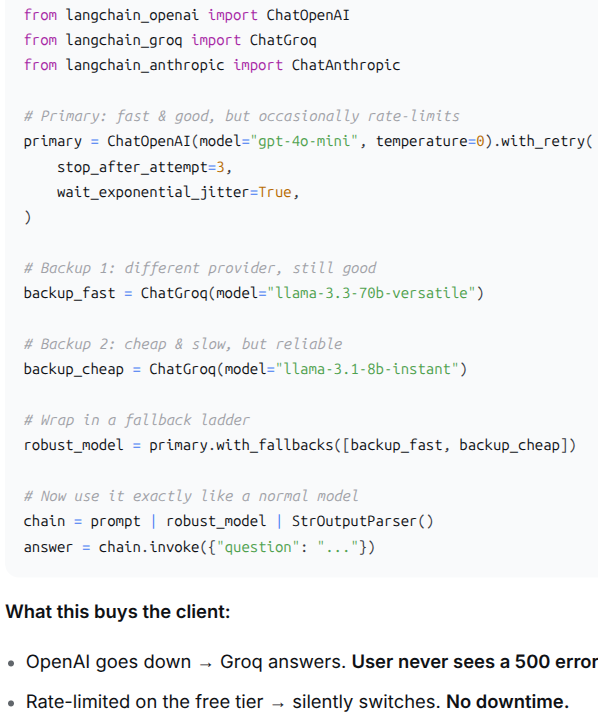

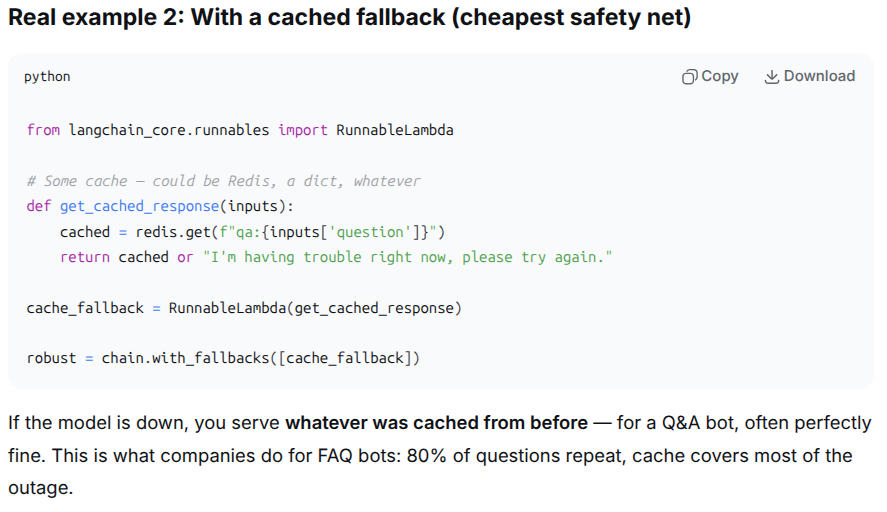

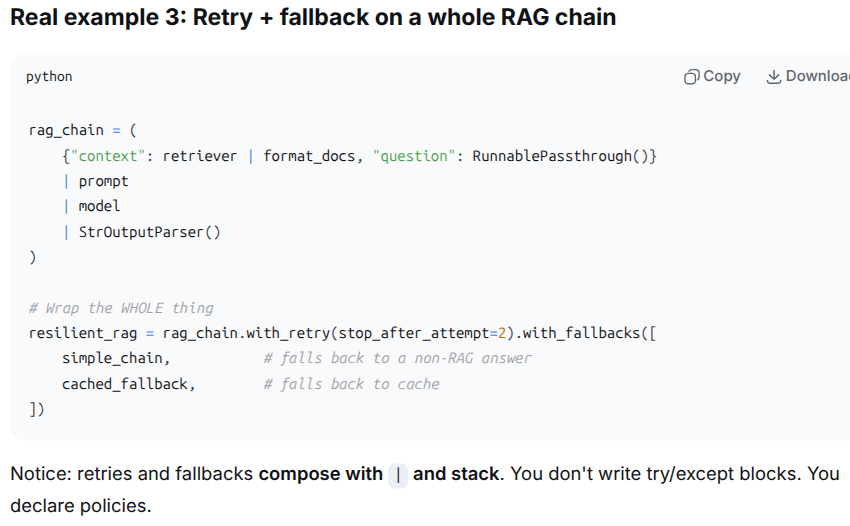

In [ ]:

# =============================================================================
# CELL: LCEL resilience - retries and fallbacks (production patterns)
# =============================================================================
# These two methods are why LCEL earns its place in production code.

# Only run this cell if langchain is installed
if HAVE_LANGCHAIN:
    # Import RunnableLambda to wrap custom Python functions as Runnables
    from langchain_core.runnables import RunnableLambda

    # --- .with_retry(): automatic retries with exponential backoff -----------
    # Create a dictionary to track how many times our flaky function is called
    # We'll increment this counter each time the function runs
    attempt_counter = {"n": 0}

    # Define a function that fails intentionally the first two times then succeeds
    # This simulates a real-world flaky service (network errors, timeouts, etc.)
    def flaky_function(x):
        """Fails the first two times, then succeeds."""
        # Increment the attempt counter to track which attempt we're on
        attempt_counter["n"] += 1
        # If we haven't reached attempt 3 yet, simulate a failure
        if attempt_counter["n"] < 3:
            # Raise an error to simulate the function failing
            raise ValueError(f"Simulated failure #{attempt_counter['n']}")
        # Once we've failed twice, return success on the third attempt
        return f"Succeeded on attempt {attempt_counter['n']}"

    # Wrap the flaky function as a RunnableLambda so we can add retry logic
    # Then add automatic retry behavior using .with_retry()
    resilient = RunnableLambda(flaky_function).with_retry(
        # Configure retry behavior:
        # Try up to 4 times total (1st attempt + 3 retries)
        stop_after_attempt=4,
        # Add exponential backoff with jitter to avoid thundering herd problem
        # (when many clients retry at the exact same time)
        wait_exponential_jitter=True,
    )

    # Print a header explaining what we're testing
    print("with_retry:")
    # Invoke the resilient function - it will fail twice, then succeed on the third try
    # .with_retry() handles all retries automatically and transparently
    print(f"  {resilient.invoke('input')}")
    # Print how many attempts were actually made
    print(f"  Total attempts made: {attempt_counter['n']}")

    # --- .with_fallbacks(): degrade gracefully -------------------------------
    # Fallbacks implement graceful degradation: if primary fails, try backup
    # This is how you build fault-tolerant systems that stay available
    
    # Define a function that always fails (simulates primary service down)
    def always_fails(x):
        # This function always raises an error (simulates a crashed service)
        raise RuntimeError("Primary model is down")

    # Define a backup function that always succeeds (simulates backup service)
    def backup(x):
        # Return a simple response from the backup system
        return "Response from the backup model"

    # Create a fallback chain: try primary, if it fails try backup
    # with_fallbacks() takes a list of backup Runnables to try in order
    with_fallback = RunnableLambda(always_fails).with_fallbacks(
        # List of backup Runnables to try if the primary fails
        [RunnableLambda(backup)]
    )

    # Print a header explaining what we're testing
    print("\nwith_fallbacks:")
    # Call the fallback chain - it will try the primary (fails), then try backup (succeeds)
    print(f"  {with_fallback.invoke('input')}")
    # Print blank line for readability
    print()
    # Explain how this pattern extends to real-world scenarios
    print("  In production this is how you chain:")
    # Show an example of a multi-level fallback chain for real-world robustness
    print("    primary_model.with_fallbacks([cheaper_model, cached_response])")
# If langchain is not installed, skip this section
else:
    print("Skipping - langchain not installed.")

with_retry:
  Succeeded on attempt 3
  Total attempts made: 3

with_fallbacks:
  Response from the backup model

  In production this is how you chain:
    primary_model.with_fallbacks([cheaper_model, cached_response])


In [ ]:
# =============================================================================
# CELL: Structured output — real, running, with Groq
# =============================================================================
# Structured output is THE pattern for any real business use case. Chat is
# a demo. Extraction, classification, and routing are the actual jobs.

# Only run this cell if langchain is installed
if HAVE_LANGCHAIN:
    # Import operating system utilities (for environment variables)
    import os
    # Import JSON for data serialization (though we won't use it directly here)
    import json
    # Import type hints:
    #   - Literal: restrict values to specific options (e.g., "billing" OR "technical")
    #   - Optional: value can be this type OR None
    from typing import Literal, Optional
    # Import BaseModel - base class for defining data structures with validation
    # Import Field - defines metadata about a model field (descriptions, defaults, etc.)
    from pydantic import BaseModel, Field
    # Import ChatGroq - the Groq model connector for structured output
    from langchain_groq import ChatGroq

    # --- 1. Define the shape you want back --------------------------------
    # Define a Pydantic model - this is like a Python dataclass but with validation
    # This model represents the structure of a customer support ticket
    class SupportTicket(BaseModel):
        """Structured representation of a customer support ticket."""

        # Field 1: category - must be one of these four options
        # Using Literal ensures the model can ONLY return these values
        # This prevents "hallucinations" where the model might return something unexpected
        category: Literal["billing", "technical", "account", "other"] = Field(
            # Field description tells the model what this field represents
            description="The main category of the issue"
        )
        # Field 2: urgency - must be one of these four priority levels
        # Urgency determines how quickly this ticket needs a response
        urgency: Literal["low", "medium", "high", "critical"] = Field(
            # Field description for the model
            description="How urgently this needs attention"
        )
        # Field 3: summary - a string (no restrictions)
        # This is the human-readable summary of the customer's problem
        summary: str = Field(
            # Field description explaining what this field contains
            description="One-sentence summary of the customer's problem"
        )
        # Field 4: order_id - optional string (can be None)
        # If the customer mentions an order ID, we capture it; otherwise it's None
        order_id: Optional[str] = Field(
            # If no order ID is found, set it to None by default
            default=None,
            # Field description explaining what to look for
            description="Order ID if mentioned, otherwise null",
        )
        # Field 5: requires_human - boolean (True or False)
        # Determines if this needs human judgment or can be automated
        requires_human: bool = Field(
            # Field description for the model
            description="True if this needs a human agent rather than automation"
        )

    # --- 2. Real model (temperature=0 for deterministic extraction) --------
    # Create a ChatGroq instance configured for reliable extraction
    model = ChatGroq(
        # Specify the model to use (good at understanding instructions)
        model="qwen/qwen3.8-27b",   # handles tool calling well
        # Set temperature to 0 for deterministic, predictable outputs
        # (temperature 0 = always pick the highest probability token)
        # (higher temperature = more randomness, more creative)
        temperature=0,
        # Pass the API key from environment variable set earlier
        api_key=os.environ["GROQ_API_KEY"],
    )

    # --- 3. Bind the schema -----------------------------------------------
    # Tell the model to output results as SupportTicket objects
    # with_structured_output() automatically:
    #   1. Adds the schema to the model's instructions
    #   2. Parses the response to create a real SupportTicket object
    #   3. Validates the output against the schema
    structured = model.with_structured_output(SupportTicket)

    # --- 4. Run it on a real ticket ---------------------------------------
    # Define a raw customer support ticket (unstructured text)
    # This is what a real customer support system would receive
    raw_ticket = "My payment failed for order #4421! This is urgent, I need it fixed today."

    # Call the structured model - it will parse the raw text and return a SupportTicket
    # The model understands the schema and formats its response accordingly
    ticket = structured.invoke(raw_ticket)

    # Print a header
    print("Parsed ticket:")
    # Show the type of object we got back (will be SupportTicket, not a dict)
    print(f"  type       : {type(ticket).__name__}   (a real SupportTicket, not a dict)")
    # Print the category the model extracted
    print(f"  category   : {ticket.category}")
    # Print the urgency level the model determined
    print(f"  urgency    : {ticket.urgency}")
    # Print the one-sentence summary the model generated
    print(f"  summary    : {ticket.summary}")
    # Print the order ID if the model found one (or None if not found)
    print(f"  order_id   : {ticket.order_id}")
    # Print whether the model thinks this needs human intervention
    print(f"  human?     : {ticket.requires_human}")
    # Verify it's actually an instance of our SupportTicket class
    print(f"  isinstance : {isinstance(ticket, SupportTicket)}")

    # --- 5. The reason this pattern wins: routing -------------------------
    # Now we can make decisions in plain Python — no string matching, no regex hacks!
    # We use the structured data to route the ticket to the right handler
    
    # Check if this is a critical issue that requires human attention
    if ticket.urgency == "critical" and ticket.requires_human:
        # Route to emergency handling
        action = "PAGE ON-CALL ENGINEER"
    # Otherwise check if this is a billing issue with an order ID (can be auto-refunded)
    elif ticket.category == "billing" and ticket.order_id:
        # Route to automated refund system
        action = f"AUTO-REFUND order {ticket.order_id}"
    # For everything else, queue for normal handling
    else:
        # Route to standard support queue
        action = "QUEUE FOR STANDARD SUPPORT"

    # Print the routing decision
    print(f"\n  → ROUTED TO: {action}")

    # --- 6. Batch extraction — the real money maker -----------------------
    # In production, you don't process one ticket at a time
    # .batch() processes multiple tickets in parallel, saving time
    # This is where structured output really shines
    print("\nBatch extraction (runs in parallel):")
    # Process three tickets concurrently using batch()
    tickets = structured.batch([
        # Ticket 1: technical issue, not urgent, no human needed initially
        "App keeps crashing on login. Annoying but not blocking.",
        # Ticket 2: billing issue, critical, definitely needs human
        "I was charged twice for my subscription, this is critical!",
        # Ticket 3: account question, routine
        "How do I change my email address?",
    ])
    # Loop through the extracted tickets and print a summary of each
    for i, t in enumerate(tickets, 1):
        # Print index, category, urgency, human flag, and summary for each ticket
        print(f"  [{i}] {t.category:<10} | {t.urgency:<8} | human={t.requires_human} | {t.summary}")

    # --- 7. Show Pydantic validation working on its own -------------------
    # Even if the model returns bad data, Pydantic validates it
    # This is a crucial safety feature - you're guaranteed valid data or an error
    print("\nValidation guard (independent of the model):")
    # Try to create a SupportTicket with invalid data
    try:
        # Try to create a ticket with an invalid category
        SupportTicket(
            category="not_a_real_category",   # This violates the Literal constraint
            urgency="high",
            summary="x",
            requires_human=False,
        )
    # Catch the validation error that Pydantic raises
    except Exception as e:
        # Print the error type and message (truncated to 100 chars)
        print(f"  Rejected: {type(e).__name__}: {str(e)[:100]}...")

# If langchain is not installed, skip this section
else:
    print("Skipping - langchain not installed.")


Parsed ticket:
  type       : SupportTicket   (a real SupportTicket, not a dict)
  category   : billing
  urgency    : critical
  summary    : Customer reports a failed payment for order #4421 and requests an urgent fix today.
  order_id   : 4421
  human?     : True
  isinstance : True

  → ROUTED TO: PAGE ON-CALL ENGINEER

Batch extraction (runs in parallel):
  [1] technical  | medium   | human=False | App crashes on login, but the issue is not blocking.
  [2] billing    | critical | human=True | Customer was charged twice for their subscription.
  [3] account    | low      | human=False | Customer wants to know how to change their email address on their account.

Validation guard (independent of the model):
  Rejected: ValidationError: 1 validation error for SupportTicket
category
  Input should be 'billing', 'technical', 'account' or...
